In [9]:
# Создайте папки для своих данных
import os
import shutil
from pathlib import Path

# Создаем структуру папок
base_dir = Path('./my_product_data')
train_dir = base_dir / 'train'
val_dir = base_dir / 'val'

# Создаем папки для категорий (пример)
categories = ['clothes', 'electronics', 'books', 'shoes', 'accessories']

for category in categories:
    (train_dir / category).mkdir(parents=True, exist_ok=True)
    (val_dir / category).mkdir(parents=True, exist_ok=True)

print("✅ Папки созданы!")
print(f"📁 Поместите тренировочные фото в: {train_dir}")
print(f"📁 Поместите валидационные фото в: {val_dir}")

✅ Папки созданы!
📁 Поместите тренировочные фото в: my_product_data\train
📁 Поместите валидационные фото в: my_product_data\val


In [10]:
# Если у вас фото в одной папке, распределите их автоматически
import random

def split_data(source_dir, train_dir, val_dir, split_ratio=0.8):
    """
    source_dir: папка с исходными фото
    train_dir: папка для обучения
    val_dir: папка для валидации
    """
    
    for category in os.listdir(source_dir):
        category_path = os.path.join(source_dir, category)
        if not os.path.isdir(category_path):
            continue
            
        # Получаем все фото в категории
        images = [f for f in os.listdir(category_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        
        # Перемешиваем
        random.shuffle(images)
        
        # Разделяем на train/val
        split_idx = int(len(images) * split_ratio)
        train_images = images[:split_idx]
        val_images = images[split_idx:]
        
        # Копируем в train
        train_cat_dir = os.path.join(train_dir, category)
        os.makedirs(train_cat_dir, exist_ok=True)
        for img in train_images:
            src = os.path.join(category_path, img)
            dst = os.path.join(train_cat_dir, img)
            shutil.copy2(src, dst)
            
        # Копируем в val
        val_cat_dir = os.path.join(val_dir, category)
        os.makedirs(val_cat_dir, exist_ok=True)
        for img in val_images:
            src = os.path.join(category_path, img)
            dst = os.path.join(val_dir, img)
            shutil.copy2(src, dst)
            
        print(f"📊 {category}: {len(train_images)} train, {len(val_images)} val")

# Используйте если у вас фото уже сгруппированы по папкам
# split_data('./my_photos', train_dir, val_dir)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import notebook

# Параметры обучения
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = len(categories)  # количество ваших категорий

# Трансформации для обучения (с аугментацией)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Трансформации для валидации
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем данные
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"📊 Найдено классов: {len(train_dataset.classes)}")
print(f"📊 Тренировочных фото: {len(train_dataset)}")
print(f"📊 Валидационных фото: {len(val_dataset)}")
print(f"📁 Классы: {train_dataset.classes}")

📊 Найдено классов: 5
📊 Тренировочных фото: 5
📊 Валидационных фото: 5
📁 Классы: ['accessories', 'books', 'clothes', 'electronics', 'shoes']


In [13]:
import os
from pathlib import Path

# Проверяем содержимое папок
base_dir = Path('./my_product_data')
train_dir = base_dir / 'train'
val_dir = base_dir / 'val'

# Смотрим что в папках
print("Содержимое train директории:")
for category in os.listdir(train_dir):
    category_path = train_dir / category
    if os.path.isdir(category_path):
        files = list(os.listdir(category_path))
        print(f"  {category}: {len(files)} файлов")
        if len(files) > 0:
            print(f"    Примеры: {files[:3]}")

Содержимое train директории:
  accessories: 2 файлов
    Примеры: ['.ipynb_checkpoints', 'WIN_20260113_07_50_41_Pro.jpg']
  books: 1 файлов
    Примеры: ['6833205462.jpg']
  clothes: 1 файлов
    Примеры: ['WIN_20260113_07_50_41_Pro.jpg']
  electronics: 1 файлов
    Примеры: ['85412f38f09ded0c4f6ab36ec625b873.jpg']
  shoes: 1 файлов
    Примеры: ['5afbc18a608d641cbe0b43c0e1f7a0c8d86364fa_original.jpeg']


In [16]:
# Загружаем предобученную модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Использую: {device}")

# Загружаем ResNet18
model = models.resnet18(pretrained=True)

# Замораживаем все слои (опционально)
for param in model.parameters():
    param.requires_grad = False

# Заменяем последний слой на наш классификатор
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

print("✅ Модель готова к обучению!")

✅ Использую: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sopka/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


C:\Users\sopka\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sopka\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [03:01<00:00, 258kB/s]

✅ Модель готова к обучению!


In [17]:
# Функция для обучения
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in notebook.tqdm(range(epochs), desc="Обучение"):
        # Тренировка
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    return train_losses, val_losses, train_accs, val_accs

# Запускаем обучение
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, EPOCHS
)

Обучение:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss: 1.6358, Train Acc: 20.00% | Val Loss: 1.6206, Val Acc: 40.00%
Epoch 2: Train Loss: 1.4950, Train Acc: 40.00% | Val Loss: 1.6350, Val Acc: 40.00%
Epoch 3: Train Loss: 1.0643, Train Acc: 100.00% | Val Loss: 1.6558, Val Acc: 40.00%
Epoch 4: Train Loss: 1.0035, Train Acc: 80.00% | Val Loss: 1.7200, Val Acc: 40.00%
Epoch 5: Train Loss: 0.9408, Train Acc: 100.00% | Val Loss: 1.7802, Val Acc: 40.00%
Epoch 6: Train Loss: 0.7185, Train Acc: 80.00% | Val Loss: 1.8834, Val Acc: 20.00%
Epoch 7: Train Loss: 0.7803, Train Acc: 60.00% | Val Loss: 2.0547, Val Acc: 20.00%
Epoch 8: Train Loss: 0.7598, Train Acc: 80.00% | Val Loss: 2.2186, Val Acc: 20.00%
Epoch 9: Train Loss: 0.5475, Train Acc: 80.00% | Val Loss: 2.3797, Val Acc: 20.00%
Epoch 10: Train Loss: 0.5829, Train Acc: 60.00% | Val Loss: 2.6046, Val Acc: 20.00%


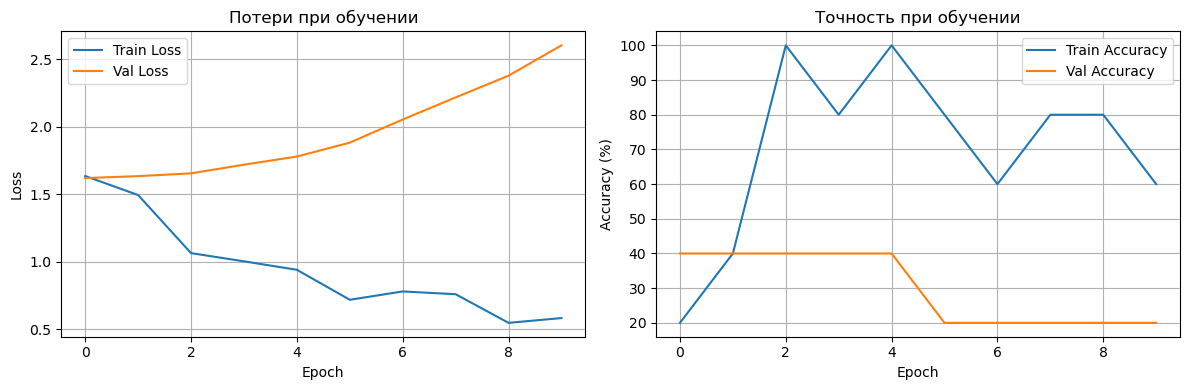

In [18]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Потери при обучении')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Точность при обучении')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Сохраняем модель
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx
}, 'my_finetuned_model.pth')

print("✅ Модель сохранена как 'my_finetuned_model.pth'")

✅ Модель сохранена как 'my_finetuned_model.pth'
